In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np

In [20]:
def plot(ax, filename, maxdb, maxdg, maxr, maxp, show_cbar=False):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_equal.performance.{filename}.db{maxdb}.dg{maxdg}.rescaling{maxr}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    probabilities = res['probabilities']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed'] 
    rescaling = res['rescaling'] 
    ps = np.asarray(res['ps'])
    
    idx = np.argsort(ps)     # indices that would sort the list
    ps = ps[idx]
    probabilities = probabilities[idx, :]
    probabilities = np.round(np.array(probabilities),3)
    norm = colors.Normalize(vmin=0, vmax=1, clip=True)
    print(np.max(probabilities))
    
    im = ax.contourf(ps, rescaling, probabilities.T, levels=np.linspace(0,1,21), norm=norm, vmin=0,vmax=1)
    
    # print(1 - np.logspace(-3,0,11, base=10)[::-1])
    # im = ax.contourf(ps, rescaling, probabilities.T, levels=1 - np.logspace(-3,0,21, base=10)[::-1], norm=norm, vmin=0,vmax=1)

    print(im)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    if show_cbar:
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$p(x^*)$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=10)
    ax.set_xlabel('p')
    ax.set_ylabel(r'$\Delta_\beta / \Delta_{\beta,\text{fixed}} = \Delta_\gamma / \Delta_{\gamma,\text{fixed}}$')
    ax.set_title(f'Performance of {filename} with $\\Delta_\\beta = {delta_b_fixed}$ and $\\Delta_\\gamma = {delta_g_fixed}$')
    return ax

1.0


<Axes: title={'center': 'Performance of test_N2_W2 with $\\Delta_\\beta = 0.63$ and $\\Delta_\\gamma = 0.16$'}, xlabel='p', ylabel='$\\Delta_\\beta / \\Delta_{\\beta,\\text{fixed}} = \\Delta_\\gamma / \\Delta_{\\gamma,\\text{fixed}}$'>

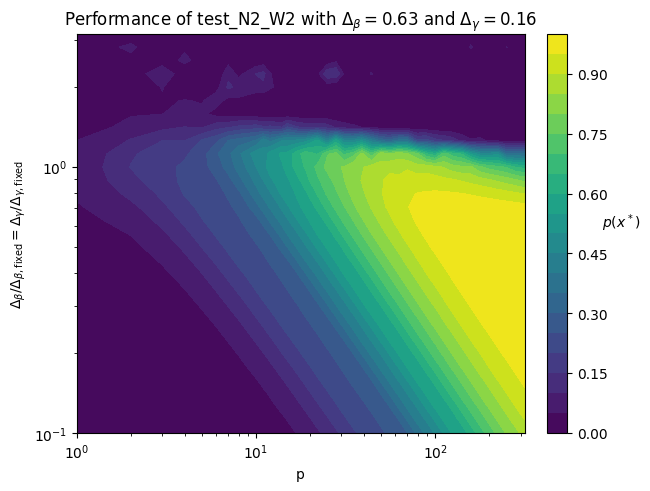

In [21]:
fig, ax = plt.subplots(layout='constrained')
db = 0.63
dg = 0.16
r = 3.16
p = 316
plot(ax, 'test_N2_W2', db, dg, r, p, True)

0.939


<Axes: title={'center': 'Performance of trivial with $\\Delta_\\beta = 0.63$ and $\\Delta_\\gamma = 0.16$'}, xlabel='p', ylabel='$\\Delta_\\beta / \\Delta_{\\beta,\\text{fixed}} = \\Delta_\\gamma / \\Delta_{\\gamma,\\text{fixed}}$'>

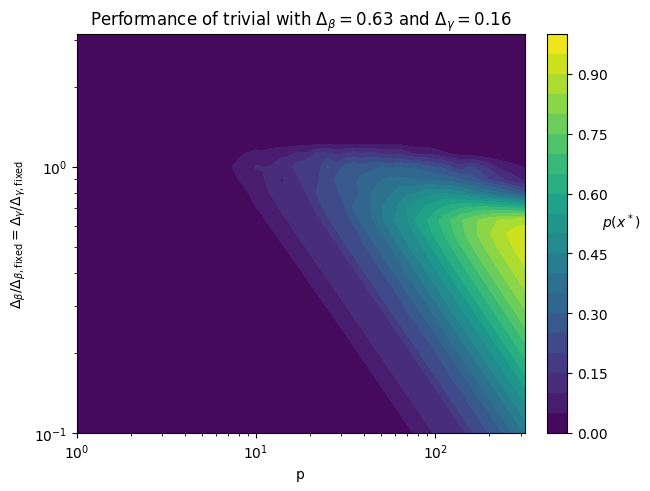

In [22]:
fig, ax = plt.subplots(layout='constrained')
db = 0.63
dg = 0.16
r = 3.16
p = 316
plot(ax, 'trivial', db, dg, r, p, True)

In [58]:
def plot_log(ax, filename, maxdb, maxdg, maxr, maxp, show_cbar=False):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_equal.performance.{filename}.db{maxdb}.dg{maxdg}.rescaling{maxr}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    probabilities = res['probabilities']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed'] 
    rescaling = res['rescaling'] 
    ps = np.asarray(res['ps'])
    
    probabilities = np.array(probabilities)
    cmap = plt.get_cmap()
    cmap.set_under('black', alpha=1.0)
    print(np.max(probabilities))
    
    eps = 10**-9
    print(np.min(np.log10(probabilities.T + eps)))
    norm = colors.Normalize(vmin=-5, vmax=0, clip=False)
    im = ax.contourf(ps, rescaling, np.log10(probabilities.T + eps), levels=np.linspace(-5,0,21), cmap=cmap, norm=norm, extend='min')
    
    print(im)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    if show_cbar:
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$\log_{10}(p(x^*))$'
        cbar.ax.set_ylabel(label, rotation=90, va="bottom", labelpad=15)
    ax.set_xlabel('p')
    ax.set_ylabel(r'$\Delta_\beta / \Delta_{\beta,\text{fixed}} = \Delta_\gamma / \Delta_{\gamma,\text{fixed}}$')
    ax.set_title(f'Performance of {filename} with $\\Delta_\\beta = {delta_b_fixed}$ and $\\Delta_\\gamma = {delta_g_fixed}$')
    return ax

0.9996128111284789
-5.12585924101781


<Axes: title={'center': 'Performance of test_N2_W2 with $\\Delta_\\beta = 0.63$ and $\\Delta_\\gamma = 0.16$'}, xlabel='p', ylabel='$\\Delta_\\beta / \\Delta_{\\beta,\\text{fixed}} = \\Delta_\\gamma / \\Delta_{\\gamma,\\text{fixed}}$'>

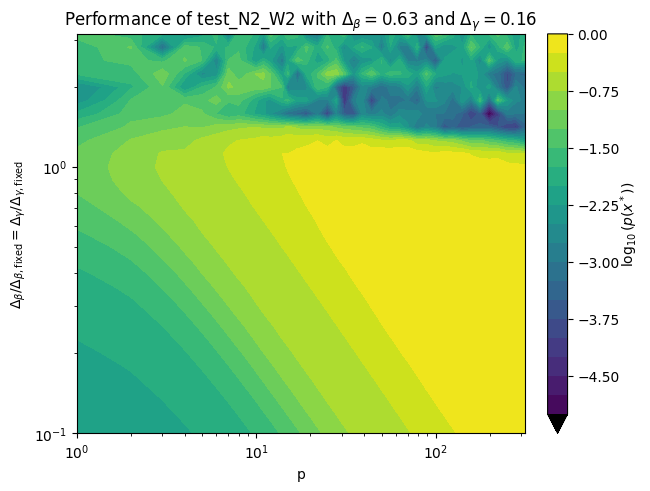

In [59]:
fig, ax = plt.subplots(layout='constrained')
db = 0.63
dg = 0.16
r = 3.16
p = 316
plot_log(ax, 'test_N2_W2', db, dg, r, p, True)

0.93928196102128
-6.664418990284921


<Axes: title={'center': 'Performance of trivial with $\\Delta_\\beta = 0.63$ and $\\Delta_\\gamma = 0.16$'}, xlabel='p', ylabel='$\\Delta_\\beta / \\Delta_{\\beta,\\text{fixed}} = \\Delta_\\gamma / \\Delta_{\\gamma,\\text{fixed}}$'>

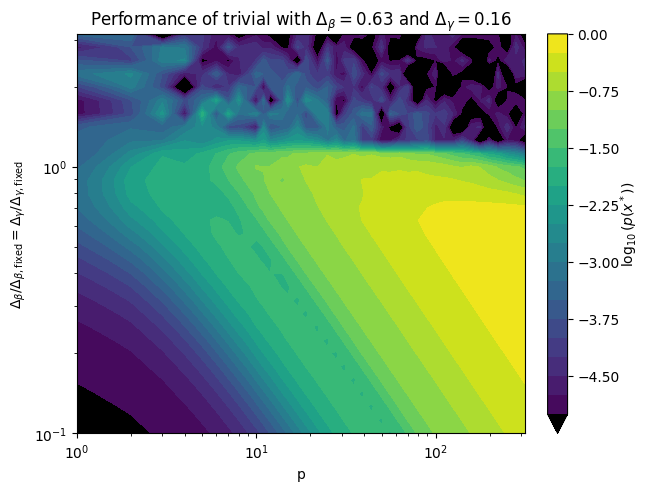

In [60]:
fig, ax = plt.subplots(layout='constrained')
db = 0.63
dg = 0.16
r = 3.16
p = 316
plot_log(ax, 'trivial', db, dg, r, p, True)

0.5052159586799321
-8.496094212547218


<Axes: title={'center': 'Performance of test_N3_W4 with $\\Delta_\\beta = 0.63$ and $\\Delta_\\gamma = 0.16$'}, xlabel='p', ylabel='$\\Delta_\\beta / \\Delta_{\\beta,\\text{fixed}} = \\Delta_\\gamma / \\Delta_{\\gamma,\\text{fixed}}$'>

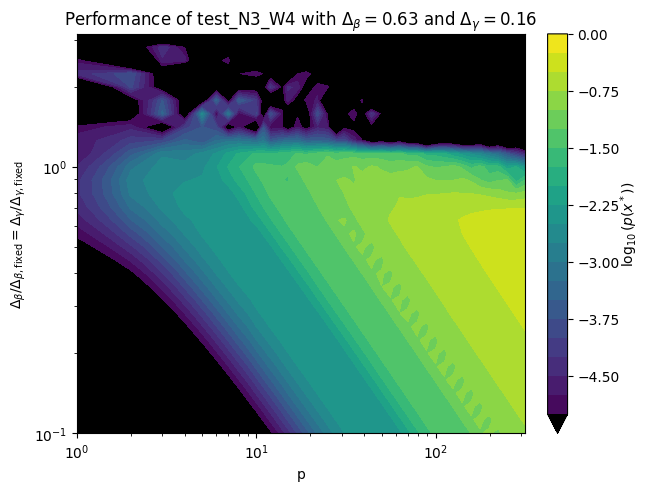

In [61]:
fig, ax = plt.subplots(layout='constrained')
db = 0.63
dg = 0.16
r = 3.16
p = 316
plot_log(ax, 'test_N3_W4', db, dg, r, p, True)